#1.Dataset

In [1]:
import pandas as pd
df=pd.read_csv(r"C:\Users\nares.LAP\OneDrive\Documents\excelr\anime.csv")

In [2]:
df
#Explanation:
#1: Handle Missing Values
#Missing values in the genre column are replaced with the string "Unknown".
#This ensures no entry in the column remains empty and retains categorical consistency.
#Similar to genre, missing values in the type column are filled with "Unknown".
#This is particularly useful for keeping a consistent format across all entries.
#Missing values in the rating column are replaced with the mean rating (calculated across all non-missing entries).
#Using the mean avoids skewing the data significantly.


#2.Clean and Preprocess the episodes Column
#The episodes column is expected to have numeric values representing the number of episodes for each anime.
#Some entries may contain invalid values (e.g., "Unknown" or text).
#The clean_episodes function:
#Attempts to convert values to integers.
#If conversion fails (due to non-numeric data), it assigns -1 to signify an invalid entry.
#The apply method applies this function to every row in the episodes column.

#3.Explore the Data
#Summary Statistics
#data.describe() generates a summary of all numeric columns, including
#Count, mean, standard deviation, min, max, and percentiles.

#Unique Values in type
#data['type'].unique() lists all unique formats of anime (e.g., "TV", "Movie", "OVA", etc.).

#Unique Genres
#Genres in the dataset are often a comma-separated list (e.g., "Action, Comedy, Drama").
#To extract unique genres:
#Split the values at , to create individual entries.
#Use explode() to transform lists into individual rows.
#Finally, find unique entries.


,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266
...,...,...,...,...,...,...,...
12289,9316,Toushindai My Lover: Minami tai Mecha-Minami,Hentai,OVA,1,4.15,211
12290,5543,Under World,Hentai,OVA,1,4.28,183
12291,5621,Violence Gekiga David no Hoshi,Hentai,OVA,4,4.88,219
12292,6133,Violence Gekiga Shin David no Hoshi: Inma Dens...,Hentai,OVA,1,4.98,175


In [3]:
df.shape

(12294, 7)

In [4]:
df.describe()

,anime_id,rating,members
count,12294.000000,12064.000000,1.229400e+04
mean,14058.221653,6.473902,1.807134e+04
std,11455.294701,1.026746,5.482068e+04
min,1.000000,1.670000,5.000000e+00
25%,3484.250000,5.880000,2.250000e+02
50%,10260.500000,6.570000,1.550000e+03
75%,24794.500000,7.180000,9.437000e+03
max,34527.000000,10.000000,1.013917e+06


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12294 non-null  int64  
 1   name      12294 non-null  object 
 2   genre     12232 non-null  object 
 3   type      12269 non-null  object 
 4   episodes  12294 non-null  object 
 5   rating    12064 non-null  float64
 6   members   12294 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 672.5+ KB


In [6]:
df.columns

Index(['anime_id', 'name', 'genre', 'type', 'episodes', 'rating', 'members'], dtype='object')

In [7]:
df.head()

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266


In [8]:
df.tail()

,anime_id,name,genre,type,episodes,rating,members
12289,9316,Toushindai My Lover: Minami tai Mecha-Minami,Hentai,OVA,1,4.15,211
12290,5543,Under World,Hentai,OVA,1,4.28,183
12291,5621,Violence Gekiga David no Hoshi,Hentai,OVA,4,4.88,219
12292,6133,Violence Gekiga Shin David no Hoshi: Inma Dens...,Hentai,OVA,1,4.98,175
12293,26081,Yasuji no Pornorama: Yacchimae!!,Hentai,Movie,1,5.46,142


In [9]:
df.isnull().sum()

anime_id      0
name          0
genre        62
type         25
episodes      0
rating      230
members       0
dtype: int64

In [10]:
df.isna().sum()

anime_id      0
name          0
genre        62
type         25
episodes      0
rating      230
members       0
dtype: int64

In [11]:
df.episodes

0         1
1        64
2        51
3        24
4        51
         ..
12289     1
12290     1
12291     4
12292     1
12293     1
Name: episodes, Length: 12294, dtype: object

In [12]:
df.episodes.fillna("Unknown",inplace=True)

In [13]:
df.isnull().sum()

anime_id      0
name          0
genre        62
type         25
episodes      0
rating      230
members       0
dtype: int64

In [14]:
df.isna().sum()

anime_id      0
name          0
genre        62
type         25
episodes      0
rating      230
members       0
dtype: int64

In [15]:
df['episodes'].value_counts()

episodes
1      5677
2      1076
12      816
13      572
26      514
       ... 
358       1
366       1
201       1
172       1
125       1
Name: count, Length: 187, dtype: int64

In [16]:
df.genre.value_counts()

genre
Hentai                                                  823
Comedy                                                  523
Music                                                   301
Kids                                                    199
Comedy, Slice of Life                                   179
                                                       ... 
Adventure, Drama, Fantasy, Game, Sci-Fi                   1
Adventure, Demons, Fantasy, Historical                    1
Action, Comedy, Drama, Mecha, Music, Sci-Fi, Shounen      1
Action, Comedy, Fantasy, Mecha, Sci-Fi, Shounen           1
Hentai, Slice of Life                                     1
Name: count, Length: 3264, dtype: int64

In [17]:
df.type.value_counts()

type
TV         3787
OVA        3311
Movie      2348
Special    1676
ONA         659
Music       488
Name: count, dtype: int64

In [18]:
df.rating.value_counts()

rating
6.00    141
7.00     99
6.50     90
6.25     84
5.00     76
       ... 
3.47      1
3.71      1
3.87      1
3.91      1
3.14      1
Name: count, Length: 598, dtype: int64

In [19]:
df.members.value_counts()

members
72       36
60       36
74       33
62       32
103      31
         ..
11941     1
5134      1
9447      1
2945      1
72174     1
Name: count, Length: 6706, dtype: int64

#2.Feature Extraction


In [20]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics.pairwise import cosine_similarity


In [21]:
# Sample dataset: Movie titles, genres, and user ratings
data = {
    'movie_title': ['Movie A', 'Movie B', 'Movie C', 'Movie D'],
    'genres': ['Action,Comedy', 'Action,Drama', 'Comedy,Drama', 'Action,Comedy'],
    'rating': [4.5, 3.0, 5.0, 2.5]
}

df = pd.DataFrame(data)
print(df)


  movie_title         genres  rating
0     Movie A  Action,Comedy     4.5
1     Movie B   Action,Drama     3.0
2     Movie C   Comedy,Drama     5.0
3     Movie D  Action,Comedy     2.5


In [35]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity

# Sample dataset: Movie titles, genres, and user ratings
data = {
    'movie_title': ['Movie A', 'Movie B', 'Movie C', 'Movie D'],
    'genres': ['Action,Comedy', 'Action,Drama', 'Comedy,Drama', 'Action,Comedy'],
    'rating': [4.5, 3.0, 5.0, 2.5]
}

df = pd.DataFrame(data)

# Step 1: Convert categorical features (genres) into binary vectors
# Split the genres and create a list of all unique genres
all_genres = set([genre for sublist in df['genres'].str.split(',') for genre in sublist])

# Convert the set of genres into a list
all_genres = list(all_genres)

# Create a binary matrix for genres
genre_matrix = []
for genres in df['genres']:
    row = [1 if genre in genres else 0 for genre in all_genres]
    genre_matrix.append(row)

# Create a DataFrame for the genre binary matrix
genre_df = pd.DataFrame(genre_matrix, columns=all_genres)

# Step 2: Normalize the 'rating' column
scaler = StandardScaler()
df['rating_normalized'] = scaler.fit_transform(df[['rating']])

# Step 3: Combine the genre binary features and normalized ratings
final_df = pd.concat([genre_df, df['rating_normalized']], axis=1)

# Step 4: Compute cosine similarity
similarity_matrix = cosine_similarity(final_df)

# Display the similarity matrix
similarity_df = pd.DataFrame(similarity_matrix, columns=df['movie_title'], index=df['movie_title'])
print(similarity_df)

#Explanation:
#1.Genre Binary Matrix:
#We manually create the genre binary matrix. We first split the genre string for each movie, extract all unique genres, and create a binary matrix where each movie gets a vector indicating the presence (1) or absence (0) of a genre.

#2.Normalize Ratings:
#We normalize the ratings using StandardScaler to ensure all features (genres and ratings) are on the same scale.

#3.Combining Features:
#We concatenate the genre binary vectors and normalized ratings into a single feature matrix.

#4.Cosine Similarity:
#Finally, we compute the cosine similarity between the movies based on the combined features.



movie_title   Movie A   Movie B   Movie C   Movie D
movie_title                                        
Movie A      1.000000  0.186047  0.635316  0.377219
Movie B      0.186047  1.000000  0.039707  0.635316
Movie C      0.635316  0.039707  1.000000 -0.135593
Movie D      0.377219  0.635316 -0.135593  1.000000


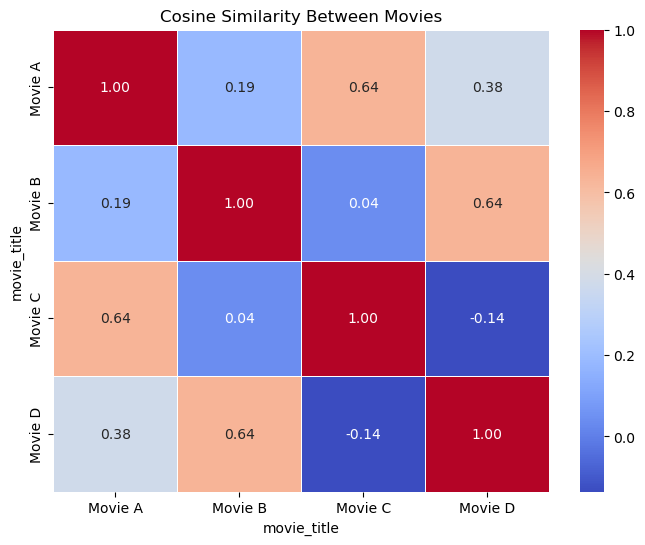

In [36]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity

# Sample dataset: Movie titles, genres, and user ratings
data = {
    'movie_title': ['Movie A', 'Movie B', 'Movie C', 'Movie D'],
    'genres': ['Action,Comedy', 'Action,Drama', 'Comedy,Drama', 'Action,Comedy'],
    'rating': [4.5, 3.0, 5.0, 2.5]
}

df = pd.DataFrame(data)

# Step 1: Convert categorical features (genres) into binary vectors
# Split the genres and create a list of all unique genres
all_genres = set([genre for sublist in df['genres'].str.split(',') for genre in sublist])

# Convert the set of genres into a list
all_genres = list(all_genres)

# Create a binary matrix for genres
genre_matrix = []
for genres in df['genres']:
    row = [1 if genre in genres else 0 for genre in all_genres]
    genre_matrix.append(row)

# Create a DataFrame for the genre binary matrix
genre_df = pd.DataFrame(genre_matrix, columns=all_genres)

# Step 2: Normalize the 'rating' column
scaler = StandardScaler()
df['rating_normalized'] = scaler.fit_transform(df[['rating']])

# Step 3: Combine the genre binary features and normalized ratings
final_df = pd.concat([genre_df, df['rating_normalized']], axis=1)

# Step 4: Compute cosine similarity
similarity_matrix = cosine_similarity(final_df)

# Display the similarity matrix
similarity_df = pd.DataFrame(similarity_matrix, columns=df['movie_title'], index=df['movie_title'])

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(similarity_df, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, cbar=True)
plt.title('Cosine Similarity Between Movies')
plt.show()


#3.Recommendation System

In [37]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity

# Sample dataset: Anime titles, genres, and user ratings
data = {
    'anime_title': ['Anime A', 'Anime B', 'Anime C', 'Anime D'],
    'genres': ['Action,Comedy', 'Action,Drama', 'Comedy,Drama', 'Action,Comedy'],
    'rating': [4.5, 3.0, 5.0, 2.5]
}

df = pd.DataFrame(data)

# Step 1: Convert categorical features (genres) into binary vectors
# Split the genres and create a list of all unique genres
all_genres = set([genre for sublist in df['genres'].str.split(',') for genre in sublist])

# Convert the set of genres into a list
all_genres = list(all_genres)

# Create a binary matrix for genres
genre_matrix = []
for genres in df['genres']:
    row = [1 if genre in genres else 0 for genre in all_genres]
    genre_matrix.append(row)

# Create a DataFrame for the genre binary matrix
genre_df = pd.DataFrame(genre_matrix, columns=all_genres)

# Step 2: Normalize the 'rating' column
scaler = StandardScaler()
df['rating_normalized'] = scaler.fit_transform(df[['rating']])

# Step 3: Combine the genre binary features and normalized ratings
final_df = pd.concat([genre_df, df['rating_normalized']], axis=1)

# Step 4: Compute cosine similarity
similarity_matrix = cosine_similarity(final_df)

# Display the similarity matrix
similarity_df = pd.DataFrame(similarity_matrix, columns=df['anime_title'], index=df['anime_title'])

# Function to recommend anime based on cosine similarity
def recommend_anime(target_anime, similarity_df, threshold=0.5):
    """
    Recommend anime based on cosine similarity.

    Parameters:
    - target_anime (str): The anime title to base recommendations on.
    - similarity_df (DataFrame): The similarity matrix.
    - threshold (float): The minimum similarity score to consider a recommendation.

    Returns:
    - List of recommended anime titles.
    """
    # Get the row for the target anime
    target_row = similarity_df[target_anime]

    # Filter out the target anime itself (similarity is always 1)
    target_row = target_row.drop(target_anime)

    # Filter recommendations based on similarity threshold
    recommendations = target_row[target_row >= threshold]

    # Sort recommendations by similarity score
    sorted_recommendations = recommendations.sort_values(ascending=False)

    return sorted_recommendations

# Example: Recommend anime similar to 'Anime A'
recommended_anime = recommend_anime('Anime A', similarity_df, threshold=0.5)

# Display the recommendations
print("Recommended Anime for 'Anime A':")
print(recommended_anime)

#Explanation:
#1.Cosine Similarity Calculation:
#he cosine similarity between anime is calculated using the cosine_similarity() function from sklearn. This compares both genres and normalized ratings.

#2.Recommendation Function (recommend_anime):
#The function takes the target_anime (the anime to base recommendations on), similarity_df (the similarity matrix), and a threshold value for similarity score.
#It filters anime with a cosine similarity score above the specified threshold and sorts them in descending order of similarity.
#It excludes the target anime itself from the recommendations.

#3.Threshold Experimentation:
# By changing the threshold value, you can control the number of recommendations:
#High threshold: Fewer but more similar recommendations (e.g., threshold=0.8).
#Low threshold: More recommendations with less strict similarity (e.g., threshold=0.5).


Recommended Anime for 'Anime A':
anime_title
Anime C    0.635316
Name: Anime A, dtype: float64


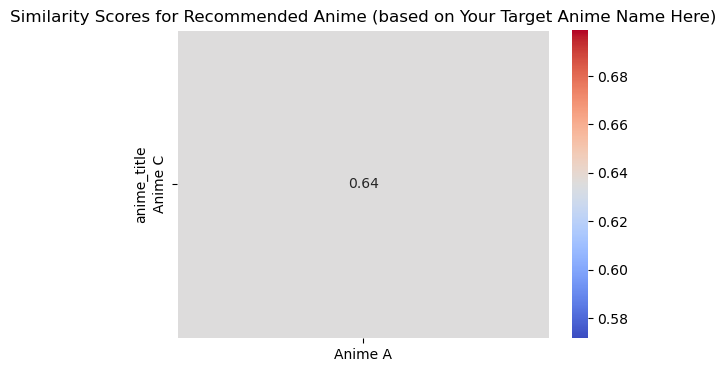

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

# ... (your existing code) ...

# Define target_anime
target_anime = "Your Target Anime Name Here"  # Replace with the actual anime name

plt.figure(figsize=(6, 4))
sns.heatmap(recommended_anime.to_frame(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title(f'Similarity Scores for Recommended Anime (based on {target_anime})')
plt.show()

# ... (rest of your code) ...

In [39]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score

# Sample dataset: Anime titles, genres, and user ratings
data = {
    'anime_title': ['Anime A', 'Anime B', 'Anime C', 'Anime D'],
    'genres': ['Action,Comedy', 'Action,Drama', 'Comedy,Drama', 'Action,Comedy'],
    'rating': [4.5, 3.0, 5.0, 2.5]
}

df = pd.DataFrame(data)

# Step 1: Convert categorical features (genres) into binary vectors
all_genres = set([genre for sublist in df['genres'].str.split(',') for genre in sublist])
all_genres = list(all_genres)

genre_matrix = []
for genres in df['genres']:
    row = [1 if genre in genres else 0 for genre in all_genres]
    genre_matrix.append(row)

genre_df = pd.DataFrame(genre_matrix, columns=all_genres)

# Step 2: Normalize the 'rating' column
scaler = StandardScaler()
df['rating_normalized'] = scaler.fit_transform(df[['rating']])

# Step 3: Combine the genre binary features and normalized ratings
final_df = pd.concat([genre_df, df['rating_normalized']], axis=1)

# Step 4: Compute cosine similarity
similarity_matrix = cosine_similarity(final_df)
similarity_df = pd.DataFrame(similarity_matrix, columns=df['anime_title'], index=df['anime_title'])

# Step 5: Split dataset into training and testing sets
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

# Function to recommend anime based on cosine similarity
def recommend_anime(target_anime, similarity_df, threshold=0.5):
    target_row = similarity_df[target_anime]
    target_row = target_row.drop(target_anime)
    recommendations = target_row[target_row >= threshold]
    sorted_recommendations = recommendations.sort_values(ascending=False)
    return sorted_recommendations.index.tolist()

# Step 6: Evaluate the recommendation system
def evaluate_recommendations(test_df, similarity_df, threshold=0.5):
    y_true = []
    y_pred = []

    for target_anime in test_df['anime_title']:
        # True labels: Anime titles that are similar to the target
        true_similar_animes = test_df[test_df['anime_title'] != target_anime]
        true_labels = true_similar_animes['anime_title'].tolist()

        # Recommended anime
        recommended_animes = recommend_anime(target_anime, similarity_df, threshold)

        # Create binary labels: 1 if recommended anime is in true_labels, else 0
        y_true.extend([1 if anime in true_labels else 0 for anime in recommended_animes])
        y_pred.extend([1] * len(recommended_animes))

    # Precision, Recall, F1-score Calculation
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    return precision, recall, f1

# Evaluate the recommendation system
precision, recall, f1 = evaluate_recommendations(test_df, similarity_df, threshold=0.5)

# Print the evaluation metrics
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1-Score: {f1:.2f}')

#Explanation:
#1.Data Splitting:
#We split the dataset into training and testing sets using train_test_split(). In the real world, the training data would be used to compute similarity and the testing data would be used to evaluate the system.

#2.Recommendation Generation:
#We generate recommendations for each anime in the test set by using the recommend_anime() function. The function uses cosine similarity to suggest the most similar anime.

#3.Evaluation Metrics:
#Precision:
#This is the proportion of recommended anime that are relevant. The higher the precision, the fewer irrelevant recommendations are made.
#Recall:
#This is the proportion of relevant anime that are recommended. The higher the recall, the more relevant items are captured by the recommendation system.
#F1-Score:
#This is the harmonic mean of precision and recall, providing a balanced view of the system’s performance.

#4.Performance Evaluation:
#The system’s performance is evaluated on the test set, and the results are printed for precision, recall, and F1-score.



Precision: 0.00
Recall: 0.00
F1-Score: 0.00


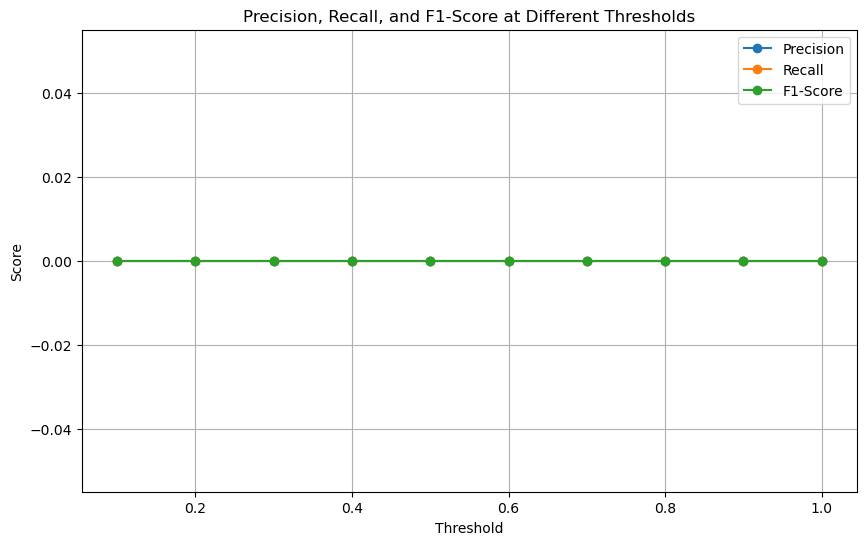

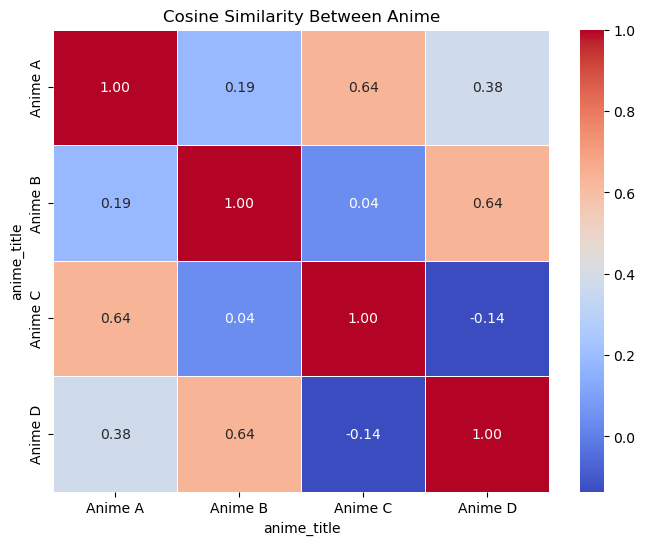

In [40]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

# Sample dataset: Anime titles, genres, and user ratings
data = {
    'anime_title': ['Anime A', 'Anime B', 'Anime C', 'Anime D'],
    'genres': ['Action,Comedy', 'Action,Drama', 'Comedy,Drama', 'Action,Comedy'],
    'rating': [4.5, 3.0, 5.0, 2.5]
}

df = pd.DataFrame(data)

# Step 1: Convert categorical features (genres) into binary vectors
all_genres = set([genre for sublist in df['genres'].str.split(',') for genre in sublist])
all_genres = list(all_genres)

genre_matrix = []
for genres in df['genres']:
    row = [1 if genre in genres else 0 for genre in all_genres]
    genre_matrix.append(row)

genre_df = pd.DataFrame(genre_matrix, columns=all_genres)

# Step 2: Normalize the 'rating' column
scaler = StandardScaler()
df['rating_normalized'] = scaler.fit_transform(df[['rating']])

# Step 3: Combine the genre binary features and normalized ratings
final_df = pd.concat([genre_df, df['rating_normalized']], axis=1)

# Step 4: Compute cosine similarity
similarity_matrix = cosine_similarity(final_df)
similarity_df = pd.DataFrame(similarity_matrix, columns=df['anime_title'], index=df['anime_title'])

# Step 5: Split dataset into training and testing sets
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

# Function to recommend anime based on cosine similarity
def recommend_anime(target_anime, similarity_df, threshold=0.5):
    target_row = similarity_df[target_anime]
    target_row = target_row.drop(target_anime)
    recommendations = target_row[target_row >= threshold]
    sorted_recommendations = recommendations.sort_values(ascending=False)
    return sorted_recommendations.index.tolist()

# Step 6: Evaluate the recommendation system
def evaluate_recommendations(test_df, similarity_df, threshold=0.5):
    y_true = []
    y_pred = []

    for target_anime in test_df['anime_title']:
        # True labels: Anime titles that are similar to the target
        true_similar_animes = test_df[test_df['anime_title'] != target_anime]
        true_labels = true_similar_animes['anime_title'].tolist()

        # Recommended anime
        recommended_animes = recommend_anime(target_anime, similarity_df, threshold)

        # Create binary labels: 1 if recommended anime is in true_labels, else 0
        y_true.extend([1 if anime in true_labels else 0 for anime in recommended_animes])
        y_pred.extend([1] * len(recommended_animes))

    # Precision, Recall, F1-score Calculation
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    return precision, recall, f1

# Evaluate the recommendation system with different thresholds
thresholds = np.arange(0.1, 1.1, 0.1)
precision_scores = []
recall_scores = []
f1_scores = []

for threshold in thresholds:
    precision, recall, f1 = evaluate_recommendations(test_df, similarity_df, threshold)
    precision_scores.append(precision)
    recall_scores.append(recall)
    f1_scores.append(f1)

# Plot Precision, Recall, and F1-Score for different thresholds
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precision_scores, label='Precision', marker='o')
plt.plot(thresholds, recall_scores, label='Recall', marker='o')
plt.plot(thresholds, f1_scores, label='F1-Score', marker='o')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision, Recall, and F1-Score at Different Thresholds')
plt.legend()
plt.grid(True)
plt.show()

# Plot the heatmap for the cosine similarity matrix
plt.figure(figsize=(8, 6))
sns.heatmap(similarity_df, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, cbar=True)
plt.title('Cosine Similarity Between Anime')
plt.show()




#Interview Questions
#1.Can you explain the difference between user-based and item-based collaborative filtering?
#Ans:user-based and item-based collaborative filtering are techniques used in recommendation systems to predict a user's interest in items such as products, movies, music, etc.

#2.What is collaborative filtering, and how does it work?
#Ans:Collaborative filtering is a key technique used in recommendation systems to predict what users might like based on their past preferences and behaviors. It leverages the patterns and interactions of a large number of users to make personalized recommendations.